# SFT Pair-Format Ablation — Eval Results

Eval-side companion to `sft_pair_ablation.py` (which analyzes SFT *training* loss).

**Source sweep**: `multirun/2026-04-29_eval_all/12-15-37/` — 32 jobs:
- 2 backbones: `Qwen3.5-9B-Base`, `Qwen3.5-9B-Instruct`
- 16 toggle combinations of four IFT-format flags during SFT data prep:
  - `ctx`  → `flow_context`
  - `appr` → `flow_appropriateness`
  - `norms` → `flow_norms_meta`
  - `conf` → `flow_confidence`

Each row in the analysis is one (backbone, variant) checkpoint evaluated on five CI benchmarks: GoldCoin-HIPAA, PrivacyLens, ConfAIde, CIRL Vignettes, VLM-GeoPrivacy.

**Identifier**: runs are matched by `config.model.lora_path` (the `checkpoint_name` heuristic collapses all 32 to `Qwen3.5-9B-{Base,Instruct}+sft_only` so we cannot use it).

**LoRA path → backbone**:
- `2026-04-28_sft_pair_ablation/20-11-11/...` → `base`
- `2026-04-28_sft_pair_ablation/18-34-09/...` → `instruct`

**PrivacyLens caveat — read before citing**: every PrivacyLens job in this sweep failed the `agent_action_format` sanity check (format adherence ~2–3% vs. 0.9 threshold), so the orchestrator never wrote metrics to W&B. We rescue them from disk in §1b and surface `agent_action_format_rate` (PL Format) so a reader can see the size of the failure. The QA-probing metric is sanity-independent and trustworthy; **leakage / helpful / adjusted-leak are computed over only ~16 of 493 prompts and should be treated as unreliable**.

**CIRL** uses the `cirl_vignettes_eval` pipeline → `cirl_accuracy` (not the trajectory-pipeline `complete` metric).

In [1]:
import subprocess, sys, re, json
from pathlib import Path

# Resolve the wicked dir so we can import its local wandb_cache module
if "__vsc_ipynb_file__" in globals():
    _NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent
elif (Path.cwd() / "wandb_cache.py").exists():
    _NB_DIR = Path.cwd()
else:
    _repo = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
    _NB_DIR = Path(_repo) / "notebooks" / "wicked"
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

import importlib, wandb_cache; importlib.reload(wandb_cache)
from wandb_cache import load_runs_raw, cache_info
import pandas as pd
import numpy as np
from IPython.display import display, Latex

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)

# Use the COLM26 cache directory — single source of truth for eval-all runs.
_REPO = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
CACHE_DIR = _REPO / "notebooks" / "COLM26" / "wandb_cache"

DS_PREFIX = {
    "goldcoin_hipaa": "gc", "privacylens": "pl",
    "vlm_geoprivacy_bench": "vlm", "confaide": "ca",
    "cirl_vignettes": "cirl",
}

# Backbone discrimination by sweep timestamp
BACKBONE_BY_SWEEP_TS = {
    "20-11-11": "base",
    "18-34-09": "instruct",
}
ABLATION_SWEEP_DIR = "2026-04-28_sft_pair_ablation"
VARIANT_RE = re.compile(r"ctx-(True|False)_appr-(True|False)_norms-(True|False)_conf-(True|False)")
TOGGLES = ["ctx", "appr", "norms", "conf"]

# Display constants used throughout the notebook
BACKBONES = ["base", "instruct"]
BACKBONE_TITLE = {"base": "Qwen3.5-9B-Base", "instruct": "Qwen3.5-9B-Instruct"}
out_dir = _NB_DIR / "tables"
out_dir.mkdir(exist_ok=True)

info = cache_info(CACHE_DIR)
print(f"Using cached W&B data from {info.get('fetched_at', 'unknown')} ({info.get('total_runs', '?')} runs)")
print(f"Cache dir: {CACHE_DIR}")

Using cached W&B data from 2026-05-01T15:03:22.931236+00:00 (2664 runs)
Cache dir: /share/pierson/matt/UAIR/notebooks/COLM26/wandb_cache


## 1. Load and filter to the SFT pair-ablation runs

We hit the raw enriched dicts (not the flat DataFrame loader) so we can read `config.model.lora_path` to identify each variant.

In [2]:
# Pull all finetuned runs from after the SFT-eval kickoff. We keep a wide
# window in case some runs straggle across day boundaries.
raw = load_runs_raw(
    cache_dir=CACHE_DIR,
    tags=["finetuned"],
    after="2026-04-29",
    before="2026-05-02",
    has_metrics=True,
)
print(f"Pulled {len(raw)} finetuned runs in date window")

def _parse_variant(run):
    """Extract (backbone, variant_str, ctx, appr, norms, conf) from a run, or None."""
    cfg = run.get("config") or {}
    model_cfg = cfg.get("model") or {}
    lora_path = str(model_cfg.get("lora_path") or "")
    if ABLATION_SWEEP_DIR not in lora_path:
        return None
    # backbone: identify which of the two parent timestamps the path goes through
    backbone = None
    for ts, label in BACKBONE_BY_SWEEP_TS.items():
        if f"/{ts}/" in lora_path:
            backbone = label
            break
    if backbone is None:
        return None
    m = VARIANT_RE.search(lora_path)
    if not m:
        return None
    ctx, appr, norms, conf = (s == "True" for s in m.groups())
    variant = m.group(0)
    return backbone, variant, ctx, appr, norms, conf

# Build flat rows: one per (run, dagspace) with metrics + parsed metadata
PRECOMPUTED = [
    "gc_applicability_f1", "gc_compliance_f1",
    "gc_applicable_f1", "gc_not_applicable_f1",
    "gc_permit_f1", "gc_forbid_f1",
    "pl_qa_accuracy", "pl_leakage_rate",
    "pl_adjusted_leakage_rate", "pl_helpful_rate",
    "vlm_q7_accuracy",
    "ca_pearson_r", "ca_accuracy", "ca_leak_rate",
    "cirl_accuracy", "cirl_integrity", "cirl_utility", "cirl_complete",
]
EVAL_PREFIXES = ("compute_metrics/eval/", "compute_trajectory_metrics/eval/")

rows = []
for r in raw:
    parsed = _parse_variant(r)
    if parsed is None:
        continue
    backbone, variant, ctx, appr, norms, conf = parsed
    row = {
        "run_id": r["run_id"],
        "run_name": r["run_name"],
        "created_at": r["created_at"],
        "dagspace": r.get("dagspace"),
        "backbone": backbone,
        "variant": variant,
        "ctx": ctx, "appr": appr, "norms": norms, "conf": conf,
    }
    for k in PRECOMPUTED:
        if k in r:
            row[k] = r[k]
    for k, v in (r.get("summary") or {}).items():
        if not isinstance(v, (int, float)):
            continue
        for prefix in EVAL_PREFIXES:
            if k.startswith(prefix):
                row[f"eval/{k[len(prefix):]}"] = v
                break
    rows.append(row)

df_raw = pd.DataFrame(rows)
df_raw["created_at"] = pd.to_datetime(df_raw["created_at"], utc=True)
print(f"Matched {len(df_raw)} (run, dagspace) rows from the SFT pair-ablation sweep")
print(f"  backbones: {sorted(df_raw['backbone'].unique())}")
print(f"  variants:  {df_raw['variant'].nunique()} unique")
print(f"  dagspaces: {sorted(df_raw['dagspace'].dropna().unique())}")
display(df_raw.head())

Pulled 127 finetuned runs in date window
Matched 127 (run, dagspace) rows from the SFT pair-ablation sweep
  backbones: ['base', 'instruct']
  variants:  16 unique
  dagspaces: ['cirl_vignettes', 'confaide', 'goldcoin_hipaa', 'vlm_geoprivacy_bench']


,run_id,run_name,created_at,dagspace,backbone,variant,ctx,appr,norms,conf,gc_applicability_f1,gc_compliance_f1,gc_applicable_f1,gc_not_applicable_f1,gc_permit_f1,gc_forbid_f1,eval/accuracy,eval/applicable/correct,eval/applicable/error,eval/applicable/f1,...,eval/subgroup/face_visible/mae,eval/subgroup/face_visible/mae_over,eval/subgroup/face_visible/mae_under,eval/subgroup/face_visible/n,eval/subgroup/face_visible/over_disclosure_rate,eval/subgroup/face_visible/under_disclosure_rate,eval/subgroup/sharing_intent_no/accuracy,eval/subgroup/sharing_intent_no/mae,eval/subgroup/sharing_intent_no/mae_over,eval/subgroup/sharing_intent_no/mae_under,eval/subgroup/sharing_intent_no/n,eval/subgroup/sharing_intent_no/over_disclosure_rate,eval/subgroup/sharing_intent_no/under_disclosure_rate,eval/subgroup/sharing_intent_yes/accuracy,eval/subgroup/sharing_intent_yes/mae,eval/subgroup/sharing_intent_yes/mae_over,eval/subgroup/sharing_intent_yes/mae_under,eval/subgroup/sharing_intent_yes/n,eval/subgroup/sharing_intent_yes/over_disclosure_rate,eval/subgroup/sharing_intent_yes/under_disclosure_rate
0,2bf83abda38dfcbb,full_eval-goldcoin_hipaa-orchestrator-20260429...,2026-04-29 16:15:59+00:00,goldcoin_hipaa,base,ctx-False_appr-False_norms-True_conf-False,False,False,True,False,0.953,0.628,0.951,0.955,0.770,0.485,0.682,98.000,9.000,0.951,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,792c64ccc10c359a,full_eval-goldcoin_hipaa-orchestrator-20260429...,2026-04-29 16:15:59+00:00,goldcoin_hipaa,base,ctx-False_appr-False_norms-False_conf-False,False,False,False,False,0.958,0.668,0.957,0.959,0.810,0.525,0.729,101.000,6.000,0.957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,dad012bbdebccee5,full_eval-goldcoin_hipaa-orchestrator-20260429...,2026-04-29 16:15:59+00:00,goldcoin_hipaa,base,ctx-False_appr-False_norms-False_conf-True,False,False,False,True,0.963,0.684,0.962,0.963,0.826,0.542,0.748,101.000,6.000,0.962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ae1064a65de682f5,cirl_vignettes_eval-cirl_vignettes-orchestrato...,2026-04-29 17:22:36+00:00,cirl_vignettes,base,ctx-False_appr-False_norms-True_conf-False,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,0.976,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1039686226d23807,cirl_vignettes_eval-cirl_vignettes-orchestrato...,2026-04-29 18:11:05+00:00,cirl_vignettes,base,ctx-False_appr-False_norms-False_conf-False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0.973,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Sanity: count per (backbone, variant). With 5 dagspaces × 32 ablations
# we expect 160 rows max, but PrivacyLens metrics are dropped (see below) so
# 4 dagspaces × 32 = 128 is the realistic floor.
coverage = (df_raw.groupby(["backbone", "variant"])["dagspace"]
            .nunique().rename("n_dagspaces").reset_index())
print(f"(backbone, variant) cells with at least one dagspace: {len(coverage)} (expect 32)")
print(f"  median dagspaces per cell: {int(coverage['n_dagspaces'].median())} (4 if PrivacyLens fails sanity)")

# PrivacyLens diagnostic: pull *all* finalize runs (no has_metrics filter) and
# check which ones reported a sanity failure.
_pl_finalize = [r for r in load_runs_raw(
                    cache_dir=CACHE_DIR,
                    after="2026-04-29", before="2026-05-02",
                    dagspace="privacylens",
                    tags=["phase:finalize"])
                if _parse_variant(r) is not None]
_pl_failed = [r for r in _pl_finalize
              if (r.get("summary") or {}).get("orchestrator/status") == "failed"]
if _pl_finalize:
    print(f"\nPrivacyLens finalize runs in scope: {len(_pl_finalize)} | "
          f"sanity-failed: {len(_pl_failed)}")
    if _pl_failed:
        sample_err = (_pl_failed[0].get("summary") or {}).get("orchestrator/error", "")
        print(f"  sample error: {sample_err[:200].replace(chr(10), ' ')}...")

(backbone, variant) cells with at least one dagspace: 32 (expect 32)
  median dagspaces per cell: 4 (4 if PrivacyLens fails sanity)

PrivacyLens finalize runs in scope: 32 | sanity-failed: 17
  sample error: sanity FAILURE in privacylens.agent_action_format (1 fail-tier threshold(s) crossed):   - format_adherence_rate=0.0203 < 0.9 (fail) Metrics from this stage cannot be trusted. Set runtime.allow_unrelia...


## 1b. PrivacyLens — rescue metrics from disk

W&B never received metrics for these 32 PrivacyLens runs because the orchestrator's `agent_action_format` sanity stage halted before `compute_metrics` could log to the run summary. But `compute_metrics` itself ran and wrote `metrics.json` to disk under each multirun job's output dir, so we read those files directly and merge them in with a `(unreliable)` caveat.

The headline trust metric is **`agent_action_format_rate`** — fraction of agent-action responses parseable by the leakage/helpfulness judges. Sanity threshold is 0.9; this sweep is at ~2–3% across the board.

In [4]:
MULTIRUN_ROOT = Path("/share/pierson/matt/UAIR/multirun/2026-04-29_eval_all/12-15-37")

_OVERRIDE_RE = re.compile(
    r"model=qwen3\.5-9b/(base|instruct)/"
    r"(ctx-(True|False)_appr-(True|False)_norms-(True|False)_conf-(True|False))"
)

def _read_overrides(job_dir):
    f = job_dir / ".hydra" / "overrides.yaml"
    if not f.exists():
        return None
    text = f.read_text()
    m = _OVERRIDE_RE.search(text)
    if not m:
        return None
    backbone, variant, ctx, appr, norms, conf = m.groups()
    return {
        "backbone": backbone, "variant": variant,
        "ctx": ctx == "True", "appr": appr == "True",
        "norms": norms == "True", "conf": conf == "True",
    }

def _load_pl_metrics(job_dir):
    f = job_dir / "privacylens" / "privacylens_eval" / "outputs" / "compute_metrics" / "metrics.json"
    if not f.exists():
        return None
    return json.loads(f.read_text())

pl_disk_rows = []
for job_dir in sorted(MULTIRUN_ROOT.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else -1):
    if not job_dir.is_dir() or not job_dir.name.isdigit():
        continue
    meta = _read_overrides(job_dir)
    metrics = _load_pl_metrics(job_dir)
    if meta is None or metrics is None:
        continue
    qa = metrics.get("qa_probing") or {}
    leak = metrics.get("leakage") or {}
    helpf = metrics.get("helpfulness") or {}
    adj = metrics.get("adjusted_leakage") or {}
    pl_disk_rows.append({
        "job": int(job_dir.name),
        **meta,
        # Headline trust signal — both leakage and helpfulness emit this; they agree
        "pl_format_adherence": leak.get("agent_action_format_rate"),
        # Counts (per the standard 493-sample PrivacyLens eval set)
        "pl_n_total":     leak.get("total"),
        "pl_n_parseable": (leak.get("total") or 0)
                          - (leak.get("skipped_no_action_format") or 0),
        # QA-probing (sanity-independent — does not use agent_action format)
        "pl_qa_accuracy": qa.get("accuracy"),
        # Leakage / helpfulness — *_among_parseable reflects only the tiny subset
        # that produced valid agent actions; *_overall_with_default_zero applies
        # default-no-leak/default-not-helpful to unparseable responses.
        "pl_leakage_rate":            leak.get("leakage_rate_among_parseable"),
        "pl_leakage_rate_overall":    leak.get("leakage_rate_overall_with_default_zero"),
        "pl_helpful_rate":            helpf.get("helpful_rate_among_parseable"),
        "pl_helpful_rate_overall":    helpf.get("helpful_rate_overall_with_default_zero"),
        # Adjusted leakage = leak rate among helpful & judged. With ~16
        # parseable / 0 helpful, this is essentially undefined for this sweep.
        "pl_adjusted_leakage_rate":   adj.get("adjusted_leakage_rate"),
        "pl_adj_n_helpful_judged":    adj.get("total_helpful_and_judged"),
    })

pl_disk = pd.DataFrame(pl_disk_rows)
print(f"Loaded PrivacyLens metrics from {len(pl_disk)} multirun jobs (expect 32)")

# Convert rates [0,1] to percent for display consistency with the rest of the notebook
RATE_COLS = [c for c in pl_disk.columns
             if c.startswith("pl_") and c.endswith(("_rate", "_adherence", "_overall", "accuracy"))]
for c in RATE_COLS:
    pl_disk[c] = pl_disk[c] * 100

display(pl_disk.sort_values(["backbone", "variant"]).round(2))

Loaded PrivacyLens metrics from 32 multirun jobs (expect 32)


,job,backbone,variant,ctx,appr,norms,conf,pl_format_adherence,pl_n_total,pl_n_parseable,pl_qa_accuracy,pl_leakage_rate,pl_leakage_rate_overall,pl_helpful_rate,pl_helpful_rate_overall,pl_adjusted_leakage_rate,pl_adj_n_helpful_judged
0,0,base,ctx-False_appr-False_norms-False_conf-False,False,False,False,False,3.250,493,16,97.840,93.750,3.040,0.000,0.000,0.000,0
1,1,base,ctx-False_appr-False_norms-False_conf-True,False,False,False,True,2.230,493,11,97.900,100.000,2.230,0.000,0.000,0.000,0
2,2,base,ctx-False_appr-False_norms-True_conf-False,False,False,True,False,2.030,493,10,98.310,90.000,1.830,0.000,0.000,0.000,0
3,3,base,ctx-False_appr-False_norms-True_conf-True,False,False,True,True,6.900,493,34,98.380,84.380,5.480,15.150,1.010,80.000,5
4,4,base,ctx-False_appr-True_norms-False_conf-False,False,True,False,False,7.710,493,38,97.090,100.000,7.510,2.940,0.200,100.000,1
5,5,base,ctx-False_appr-True_norms-False_conf-True,False,True,False,True,4.460,493,22,97.020,59.090,2.640,72.730,3.250,62.500,16
6,6,base,ctx-False_appr-True_norms-True_conf-False,False,True,True,False,3.250,493,16,98.110,93.750,3.040,18.750,0.610,100.000,3
7,7,base,ctx-False_appr-True_norms-True_conf-True,False,True,True,True,5.680,493,28,98.040,78.570,4.460,21.430,1.220,50.000,6
8,8,base,ctx-True_appr-False_norms-False_conf-False,True,False,False,False,4.060,493,20,97.700,100.000,4.060,0.000,0.000,0.000,0
9,9,base,ctx-True_appr-False_norms-False_conf-True,True,False,False,True,2.430,493,12,97.700,75.000,1.830,33.330,0.810,50.000,4


### How badly did sanity fail?

`agent_action_format_rate` is the fraction of the 493 PrivacyLens prompts where the model returned a parseable agent-action JSON. The sanity-stage threshold is **0.9**. Bars below show the gap.

Format adherence (%) — sanity threshold = 90.0%
  n runs:  32
  min:     2.03
  median:  49.09
  max:     99.59
  passing sanity (>= 90.0%): 15 / 32

By backbone:


,count,min,median,max
backbone,,,,
base,16,2.030,3.750,10.550
instruct,16,87.630,98.480,99.590


/tmp/ipykernel_2489030/2818347196.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["vlabel"], rotation=60, ha="right",
/tmp/ipykernel_2489030/2818347196.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["vlabel"], rotation=60, ha="right",


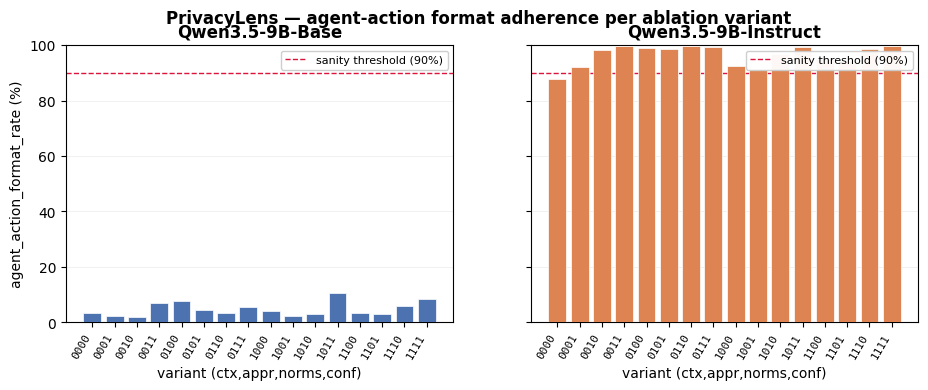

In [5]:
import matplotlib.pyplot as plt

SANITY_THRESHOLD_PCT = 90.0  # 0.9 in raw, ×100 here

# Headline distribution
adh = pl_disk["pl_format_adherence"]
print(f"Format adherence (%) — sanity threshold = {SANITY_THRESHOLD_PCT}%")
print(f"  n runs:  {len(adh)}")
print(f"  min:     {adh.min():.2f}")
print(f"  median:  {adh.median():.2f}")
print(f"  max:     {adh.max():.2f}")
print(f"  passing sanity (>= {SANITY_THRESHOLD_PCT}%): "
      f"{int((adh >= SANITY_THRESHOLD_PCT).sum())} / {len(adh)}")

# Per-(backbone) summary
print("\nBy backbone:")
display(pl_disk.groupby("backbone")["pl_format_adherence"]
                 .agg(["count", "min", "median", "max"]).round(2))

# Bar plot — variants ordered the same way as the rest of the notebook
def _bitmask(r):
    return r["ctx"] * 8 + r["appr"] * 4 + r["norms"] * 2 + r["conf"] * 1
pl_disk = pl_disk.assign(_bbo=pl_disk["backbone"].map({"base": 0, "instruct": 1}),
                         _bbm=pl_disk.apply(_bitmask, axis=1)) \
                 .sort_values(["_bbo", "_bbm"]).drop(columns=["_bbo", "_bbm"]) \
                 .reset_index(drop=True)

def _label(r):
    return "".join("1" if r[t] else "0" for t in TOGGLES)
pl_disk["vlabel"] = pl_disk.apply(_label, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
backbone_color = {"base": "#4C72B0", "instruct": "#DD8452"}
for ax, bb in zip(axes, ["base", "instruct"]):
    sub = pl_disk[pl_disk["backbone"] == bb]
    ax.bar(sub["vlabel"], sub["pl_format_adherence"],
           color=backbone_color[bb], edgecolor="white", linewidth=0.5, zorder=3)
    ax.axhline(SANITY_THRESHOLD_PCT, color="crimson", lw=1, ls="--",
               label=f"sanity threshold ({SANITY_THRESHOLD_PCT:.0f}%)", zorder=2)
    ax.set_title(BACKBONE_TITLE[bb], fontweight="bold")
    ax.set_xlabel("variant (ctx,appr,norms,conf)")
    ax.set_xticklabels(sub["vlabel"], rotation=60, ha="right",
                        fontfamily="monospace", fontsize=8)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25, lw=0.5)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.95)
axes[0].set_ylabel("agent_action_format_rate (%)")
fig.suptitle("PrivacyLens — agent-action format adherence per ablation variant",
             fontweight="bold")
fig.savefig(out_dir / "sft_pair_ablation_pl_sanity.pdf")
plt.show()

## 2. Pivot per-dagspace metrics into one row per (backbone, variant)


In [6]:
# De-duplicate: keep last run per (backbone, variant, dagspace) by created_at
df_dedup = df_raw.sort_values("created_at").drop_duplicates(
    subset=["backbone", "variant", "dagspace"], keep="last"
)

metric_cols_all = [c for c in df_dedup.columns
                   if c.startswith(("gc_", "pl_", "vlm_", "ca_", "cirl_", "eval/"))]

def _pivot_dagspace(df, dagspace):
    sub = df[df["dagspace"] == dagspace]
    if sub.empty:
        return pd.DataFrame()
    prefix = DS_PREFIX.get(dagspace, dagspace)
    keep = [c for c in metric_cols_all if sub[c].notna().any()]
    out = sub[["backbone", "variant", "ctx", "appr", "norms", "conf"] + keep].copy()
    rename = {c: f"{prefix}/{c[5:]}" for c in keep if c.startswith("eval/")}
    return out.rename(columns=rename)

df_table = pd.DataFrame()
for ds in sorted(df_dedup["dagspace"].dropna().unique()):
    piv = _pivot_dagspace(df_dedup, ds)
    if piv.empty:
        continue
    if df_table.empty:
        df_table = piv
    else:
        keys = ["backbone", "variant", "ctx", "appr", "norms", "conf"]
        overlap = [c for c in piv.columns if c in df_table.columns and c not in keys]
        if overlap:
            piv = piv.drop(columns=overlap)
        df_table = df_table.merge(piv, on=keys, how="outer")

# Defragment after wide-merge so subsequent .insert calls don't warn
df_table = df_table.copy()

# Convert [0,1] → percent for any metric col
metric_out_cols = [c for c in df_table.columns
                   if c not in {"backbone", "variant", "ctx", "appr", "norms", "conf"}]
for c in metric_out_cols:
    if pd.api.types.is_numeric_dtype(df_table[c]):
        df_table[c] = df_table[c] * 100

# Sort: backbone (base, instruct), then by toggle bitmask (000 → 1111)
sort_keys = pd.DataFrame({
    "_bbo": df_table["backbone"].map({"base": 0, "instruct": 1}),
    "_bbm": (df_table["ctx"].astype(int) * 8
             + df_table["appr"].astype(int) * 4
             + df_table["norms"].astype(int) * 2
             + df_table["conf"].astype(int)),
}, index=df_table.index)
df_table = (df_table.assign(**sort_keys)
            .sort_values(["_bbo", "_bbm"])
            .drop(columns=["_bbm", "_bbo"])
            .reset_index(drop=True))

print(f"Full pivoted table: {df_table.shape}")
display(df_table.round(2))

Full pivoted table: (32, 163)


,backbone,variant,ctx,appr,norms,conf,cirl/accuracy,cirl/parseable,cirl/total,cirl/unparseable_count,cirl/unparseable_rate,cirl_accuracy,cirl/accept_count,cirl/reject_count,cirl/seed/accept_count,cirl/seed/accuracy,cirl/seed/accuracy_among_parseable,cirl/seed/parseable,cirl/seed/reject_count,cirl/seed/total,...,vlm/subgroup/face_visible/mae,vlm/subgroup/face_visible/mae_over,vlm/subgroup/face_visible/mae_under,vlm/subgroup/face_visible/n,vlm/subgroup/face_visible/over_disclosure_rate,vlm/subgroup/face_visible/under_disclosure_rate,vlm/subgroup/sharing_intent_no/accuracy,vlm/subgroup/sharing_intent_no/mae,vlm/subgroup/sharing_intent_no/mae_over,vlm/subgroup/sharing_intent_no/mae_under,vlm/subgroup/sharing_intent_no/n,vlm/subgroup/sharing_intent_no/over_disclosure_rate,vlm/subgroup/sharing_intent_no/under_disclosure_rate,vlm/subgroup/sharing_intent_yes/accuracy,vlm/subgroup/sharing_intent_yes/mae,vlm/subgroup/sharing_intent_yes/mae_over,vlm/subgroup/sharing_intent_yes/mae_under,vlm/subgroup/sharing_intent_yes/n,vlm/subgroup/sharing_intent_yes/over_disclosure_rate,vlm/subgroup/sharing_intent_yes/under_disclosure_rate
0,base,ctx-False_appr-False_norms-False_conf-False,False,False,False,False,97.260,98600.000,98600.000,0.000,0.000,97.260,2700.000,95900.000,1000.000,97.970,97.970,49300.000,48300.000,49300.000,...,47.380,106.310,112.500,38200.000,29.060,14.660,58.640,44.090,105.840,108.890,44000.000,31.140,10.230,46.060,58.020,112.500,106.540,34300.000,9.330,44.610
1,base,ctx-False_appr-False_norms-False_conf-True,False,False,False,True,97.260,98600.000,98600.000,0.000,0.000,97.260,2700.000,95900.000,1000.000,97.970,97.970,49300.000,48300.000,49300.000,...,47.380,106.310,112.500,38200.000,29.060,14.660,58.410,44.320,105.800,108.890,44000.000,31.360,10.230,46.060,58.020,112.500,106.540,34300.000,9.330,44.610
2,base,ctx-False_appr-False_norms-True_conf-False,False,False,True,False,97.570,98600.000,98600.000,0.000,0.000,97.570,2400.000,96200.000,900.000,98.170,98.170,49300.000,48400.000,49300.000,...,47.380,106.190,110.910,38200.000,29.580,14.400,58.860,43.410,105.040,107.140,44000.000,31.590,9.550,46.940,57.140,109.380,107.330,34300.000,9.330,43.730
3,base,ctx-False_appr-False_norms-True_conf-True,False,False,True,True,97.360,98600.000,98600.000,0.000,0.000,97.360,2600.000,96000.000,900.000,98.170,98.170,49300.000,48400.000,49300.000,...,47.380,106.190,110.910,38200.000,29.580,14.400,58.860,43.410,105.070,106.980,44000.000,31.360,9.770,46.940,57.140,109.380,107.330,34300.000,9.330,43.730
4,base,ctx-False_appr-True_norms-False_conf-False,False,True,False,False,97.060,98600.000,98600.000,0.000,0.000,97.060,2900.000,95700.000,1100.000,97.770,97.770,49300.000,48200.000,49300.000,...,47.380,106.190,110.910,38200.000,29.580,14.400,58.860,43.410,105.040,107.140,44000.000,31.590,9.550,46.940,57.140,109.380,107.330,34300.000,9.330,43.730
5,base,ctx-False_appr-True_norms-False_conf-True,False,True,False,True,96.750,98600.000,98600.000,0.000,0.000,96.750,3200.000,95400.000,1200.000,97.570,97.570,49300.000,48100.000,49300.000,...,47.380,106.310,112.500,38200.000,29.060,14.660,58.410,44.320,105.800,108.890,44000.000,31.360,10.230,46.060,58.020,112.500,106.540,34300.000,9.330,44.610
6,base,ctx-False_appr-True_norms-True_conf-False,False,True,True,False,96.960,98600.000,98600.000,0.000,0.000,96.960,3000.000,95600.000,1100.000,97.770,97.770,49300.000,48200.000,49300.000,...,47.380,106.190,110.910,38200.000,29.580,14.400,58.860,43.410,105.070,106.980,44000.000,31.360,9.770,46.940,57.140,109.380,107.330,34300.000,9.330,43.730
7,base,ctx-False_appr-True_norms-True_conf-True,False,True,True,True,97.060,98600.000,98600.000,0.000,0.000,97.060,2900.000,95700.000,1000.000,97.970,97.970,49300.000,48300.000,49300.000,...,47.380,106.310,112.500,38200.000,29.060,14.660,58.410,44.320,105.800,108.890,44000.000,31.360,10.230,46.060,58.020,112.500,106.540,34300.000,9.330,44.610
8,base,ctx-True_appr-False_norms-False_conf-False,True,False,False,False,97.260,98600.000,

In [7]:
# Merge disk-recovered PrivacyLens metrics into the headline table.
# Keep only metric columns (drop pl_disk's local _bbm/_bbo/job/vlabel/counts).
_pl_metric_cols = [c for c in pl_disk.columns
                   if c.startswith("pl_") and not c.endswith(("_n_total", "_n_parseable",
                                                              "_adj_n_helpful_judged"))]
_pl_merge = pl_disk[["backbone", "variant"] + _pl_metric_cols].copy()
df_table = df_table.merge(_pl_merge, on=["backbone", "variant"], how="left").copy()
print(f"Merged {len(_pl_metric_cols)} PrivacyLens columns into df_table → shape {df_table.shape}")

Merged 7 PrivacyLens columns into df_table → shape (32, 170)


## 3. Headline metric set

Same set as `zero_shot_vs_sft.ipynb` so this notebook composes with the others.

In [8]:
# (df_column, display_label, lower_is_better)
#
# CIRL: eval_all uses the cirl_vignettes_eval pipeline, which logs
# cirl_accuracy via the precomputed metric column (NOT cirl/complete from
# the trajectory pipeline).
#
# PrivacyLens metrics are recovered from disk (compute_metrics ran but
# didn't reach W&B because the orchestrator-level sanity stage halted on
# format adherence ~2-3% vs threshold 0.9). They are flagged as
# UNRELIABLE in the final tables.
PAPER_METRICS = [
    ("gc_applicability_f1",      "App F1",          False),
    ("gc_compliance_f1",         "Comp F1",         False),
    ("pl_qa_accuracy",           "QA Acc",          False),
    ("pl_adjusted_leakage_rate", "Adj Leak",        True),
    ("pl_helpful_rate",          "Helpful",         False),
    ("pl_format_adherence",      "PL Format",       False),
    ("ca/pearson_r",             "Pearson r",       False),
    ("cirl_accuracy",            "CIRL Acc",        False),
    ("vlm/Q7/accuracy",          "Q7 Acc",          False),
]
# Metrics whose values are not trustworthy without a sanity-passing run
UNRELIABLE_METRICS = {"pl_qa_accuracy", "pl_adjusted_leakage_rate",
                      "pl_helpful_rate", "pl_format_adherence"}

_missing = [(c, l) for c, l, _ in PAPER_METRICS if c not in df_table.columns]
PAPER_METRICS = [(c, l, lb) for c, l, lb in PAPER_METRICS if c in df_table.columns]
if _missing:
    print(f"Headline metrics absent from table (skipped): {_missing}")
print(f"Headline metrics in use: {[l for _, l, _ in PAPER_METRICS]}")
print(f"Unreliable (sanity-failed): {sorted(UNRELIABLE_METRICS & {c for c, _, _ in PAPER_METRICS})}")

metric_cols = [c for c, _, _ in PAPER_METRICS]
label_by_col = {c: l for c, l, _ in PAPER_METRICS}
lower_better = {c for c, _, lb in PAPER_METRICS if lb}

Headline metrics in use: ['App F1', 'Comp F1', 'QA Acc', 'Adj Leak', 'Helpful', 'PL Format', 'Pearson r', 'CIRL Acc', 'Q7 Acc']
Unreliable (sanity-failed): ['pl_adjusted_leakage_rate', 'pl_format_adherence', 'pl_helpful_rate', 'pl_qa_accuracy']


## 4. Toggle main effects

For each backbone × metric × toggle T, the **main effect** is the mean of all 8 variants where T=True minus the mean of the 8 where T=False. A positive number means *including this CI metadata field in the SFT target* helps that metric (or hurts it for lower-is-better metrics, where a negative main effect is good).

In [9]:
def main_effects(df, metrics, toggles):
    """Return long-form DataFrame: one row per (backbone, metric, toggle)."""
    out = []
    for backbone, sub in df.groupby("backbone"):
        for m in metrics:
            if m not in sub.columns:
                continue
            for t in toggles:
                on = sub.loc[sub[t], m].mean()
                off = sub.loc[~sub[t], m].mean()
                out.append({
                    "backbone": backbone, "metric": label_by_col.get(m, m),
                    "metric_col": m, "toggle": t,
                    "on_mean": on, "off_mean": off, "effect": on - off,
                    "lower_is_better": m in lower_better,
                })
    return pd.DataFrame(out)

df_eff = main_effects(df_table, metric_cols, TOGGLES)

# Pretty pivot: rows = (backbone, metric), columns = toggle, values = effect
eff_table = (df_eff
             .pivot_table(index=["backbone", "metric"], columns="toggle",
                          values="effect")
             [TOGGLES])
# Reorder rows so metrics follow PAPER_METRICS order
metric_order = [l for _, l, _ in PAPER_METRICS]
eff_table = eff_table.reindex(
    pd.MultiIndex.from_product([["base", "instruct"], metric_order],
                               names=["backbone", "metric"])
).dropna(how="all")
print("Main effect (Δ percentage points): on - off")
display(eff_table.round(2))

Main effect (Δ percentage points): on - off


toggle                ctx   appr  norms   conf
backbone metric                               
base     App F1    -0.410  0.180 -0.180  0.410
         Comp F1   -0.990  4.740 -6.040  2.230
         QA Acc     0.060 -0.110  0.580 -0.110
         Adj Leak   5.730 50.520 19.480 10.100
         Helpful    2.500 20.180 -4.550 22.220
         PL Format  0.660  0.910  1.880  1.370
         Pearson r -2.440  5.650 -6.090 -1.440
         CIRL Acc  -0.080 -0.350  0.180 -0.200
         Q7 Acc     0.050 -0.110  0.050 -0.400
instruct App F1    -1.950  0.880 -2.190 -0.290
         Comp F1   -0.280 -1.940  2.860 -4.330
         QA Acc     0.010 -0.260  0.350 -0.250
         Adj Leak  -1.090  0.860 -1.510  1.840
         Helpful    0.170 -0.390 -0.150 -0.680
         PL Format -0.910  3.350  5.170  0.810
         Pearson r -0.590  2.800 -1.920  0.180
         CIRL Acc  -0.080 -0.890 -0.860 -0.610
         Q7 Acc    -0.080  0.110 -0.050  0.110

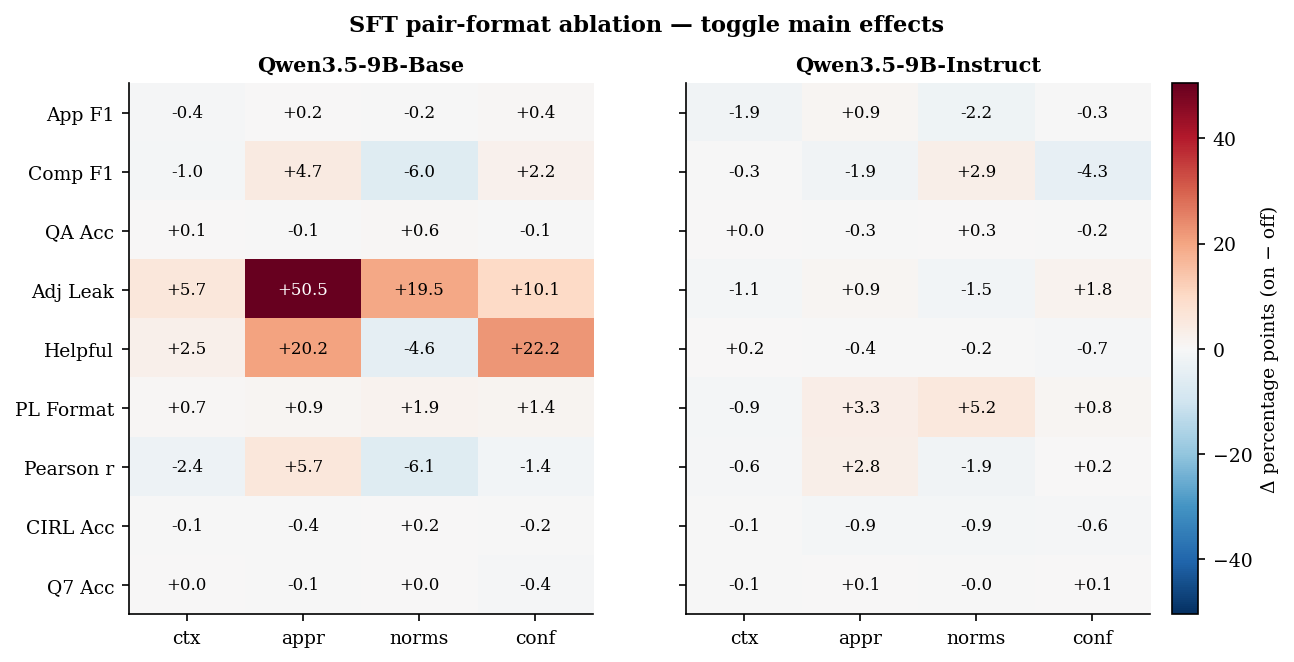

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BACKBONES = ["base", "instruct"]
BACKBONE_TITLE = {"base": "Qwen3.5-9B-Base", "instruct": "Qwen3.5-9B-Instruct"}

# Heatmap of main effects: rows=metric, cols=toggle
fig, axes = plt.subplots(1, len(BACKBONES), figsize=(4.6 * len(BACKBONES), 4.6),
                          sharey=True)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

vmax = float(np.nanmax(np.abs(eff_table.values))) or 1.0
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.get_cmap("RdBu_r")

for ax, bb in zip(axes, BACKBONES):
    if bb not in eff_table.index.get_level_values(0):
        ax.set_visible(False); continue
    sub = eff_table.loc[bb]
    im = ax.imshow(sub.values, cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(TOGGLES)))
    ax.set_xticklabels(TOGGLES)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index)
    ax.set_title(BACKBONE_TITLE[bb], fontweight="bold")
    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            v = sub.values[i, j]
            if pd.isna(v):
                continue
            ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                    fontsize=8, color="black" if abs(v) < vmax * 0.55 else "white")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Δ percentage points (on − off)")
fig.suptitle("SFT pair-format ablation — toggle main effects", fontweight="bold")
out_dir = _NB_DIR / "tables"
out_dir.mkdir(exist_ok=True)
fig.savefig(out_dir / "sft_pair_ablation_main_effects.pdf")
plt.show()

## 5. Per-variant heatmap

16 variants × headline metrics, per backbone. Each cell colored by **within-metric, within-backbone z-score** so signals from differently-scaled metrics are comparable.

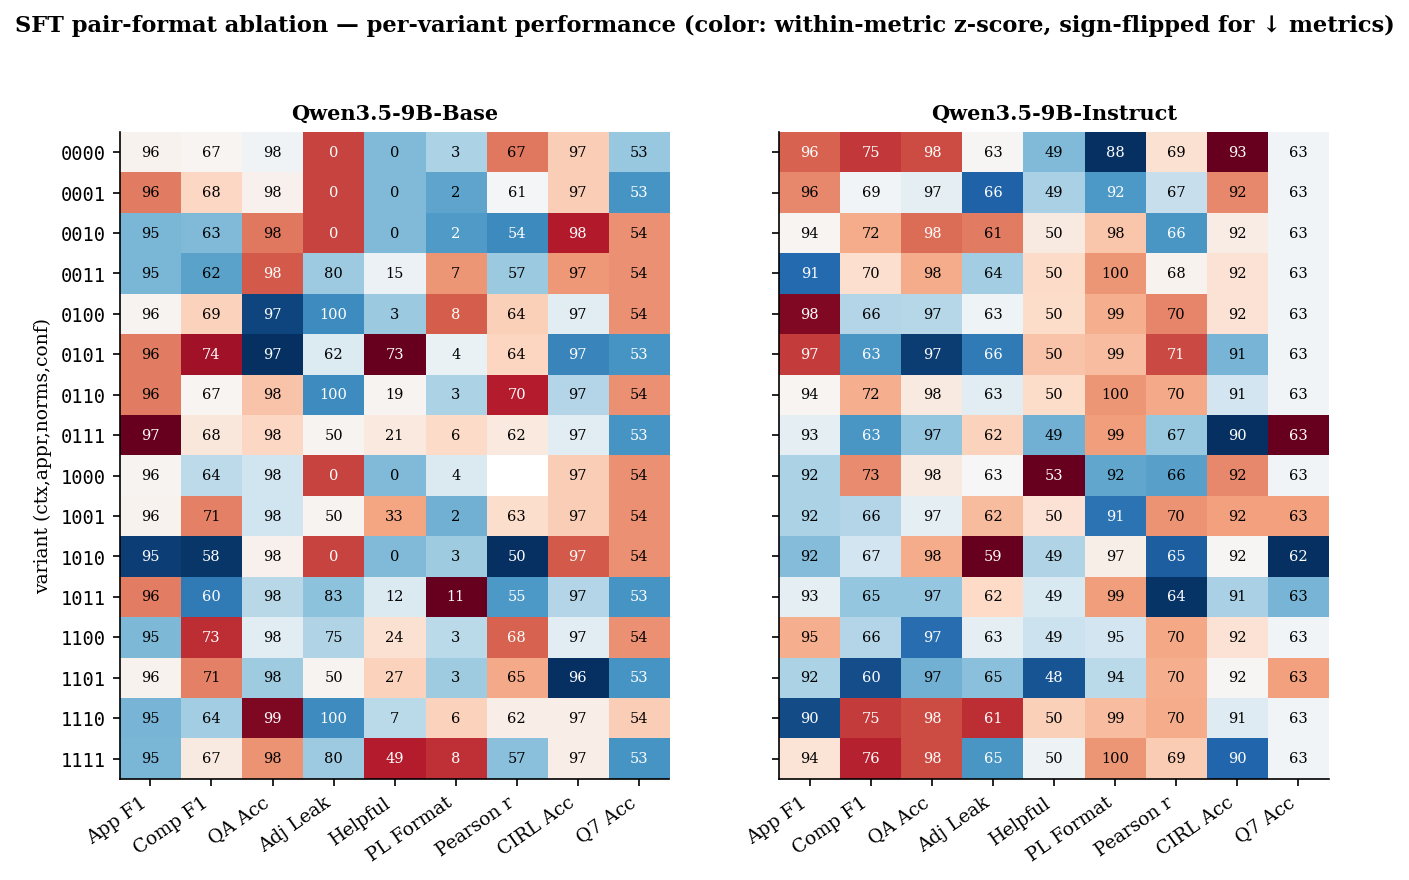

In [11]:
# Make a tidy variant label like "1011" (ctx,appr,norms,conf) for compact display
def _label(row):
    return "".join("1" if row[t] else "0" for t in TOGGLES)
df_table["vlabel"] = df_table.apply(_label, axis=1)

fig, axes = plt.subplots(1, len(BACKBONES), figsize=(5.2 * len(BACKBONES), 5.6),
                         sharey=True)
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for ax, bb in zip(axes, BACKBONES):
    sub = (df_table[df_table["backbone"] == bb]
           .sort_values("vlabel")[["vlabel"] + metric_cols]
           .set_index("vlabel"))
    if sub.empty:
        ax.set_visible(False); continue
    # Sign-flip lower-is-better metrics for colour, leave annotation in raw units
    z = sub.copy()
    for c in z.columns:
        sign = -1 if c in lower_better else 1
        col = z[c] * sign
        mu, sd = col.mean(), col.std(ddof=0)
        z[c] = (col - mu) / sd if sd and not np.isnan(sd) else 0.0
    ax.imshow(z.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(metric_cols)))
    ax.set_xticklabels([label_by_col[c] for c in metric_cols], rotation=35, ha="right")
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontfamily="monospace")
    ax.set_title(BACKBONE_TITLE[bb], fontweight="bold")
    for i in range(sub.shape[0]):
        for j, c in enumerate(metric_cols):
            v = sub.values[i, j]
            if pd.isna(v):
                continue
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                    color="black" if abs(z.values[i, j]) < 1.1 else "white")
axes[0].set_ylabel("variant (ctx,appr,norms,conf)")
fig.suptitle("SFT pair-format ablation — per-variant performance (color: within-metric z-score, sign-flipped for ↓ metrics)",
             fontweight="bold", y=1.02)
fig.savefig(out_dir / "sft_pair_ablation_per_variant.pdf")
plt.show()

## 6. Best variant per (backbone, metric)


In [12]:
best_rows = []
for bb in BACKBONES:
    sub = df_table[df_table["backbone"] == bb]
    if sub.empty:
        continue
    for c, l, lb in PAPER_METRICS:
        if c not in sub.columns or sub[c].isna().all():
            best_rows.append({"backbone": bb, "metric": l, "best_variant": None,
                              "best_value": np.nan, "all_True_value": np.nan,
                              "all_False_value": np.nan, "spread": np.nan})
            continue
        idx = sub[c].idxmin() if lb else sub[c].idxmax()
        best_v = sub.loc[idx, "vlabel"]
        best_val = sub.loc[idx, c]
        all_T = sub.loc[sub["vlabel"] == "1111", c]
        all_F = sub.loc[sub["vlabel"] == "0000", c]
        best_rows.append({
            "backbone": bb, "metric": l,
            "best_variant": best_v, "best_value": best_val,
            "all_True_value": float(all_T.iloc[0]) if len(all_T) else np.nan,
            "all_False_value": float(all_F.iloc[0]) if len(all_F) else np.nan,
            "spread": sub[c].max() - sub[c].min(),
        })
df_best = pd.DataFrame(best_rows)
display(df_best.round(2))

,backbone,metric,best_variant,best_value,all_True_value,all_False_value,spread
0,base,App F1,0111,96.730,95.320,95.790,1.870
1,base,Comp F1,0101,73.900,67.380,66.750,15.760
2,base,QA Acc,1110,98.650,98.240,97.840,1.620
3,base,Adj Leak,0000,0.000,80.000,0.000,100.000
4,base,Helpful,0101,72.730,48.780,0.000,72.730
5,base,PL Format,1011,10.550,8.320,3.250,8.520
6,base,Pearson r,0110,69.700,56.820,66.950,19.910
7,base,CIRL Acc,0010,97.570,97.160,97.260,1.220
8,base,Q7 Acc,0010,53.640,53.000,53.130,0.640
9,instruct,App F1,0100,97.660,94.370,96.260,7.570


## 7. LaTeX — main-effects table


In [13]:
def build_main_effects_latex(eff_table: pd.DataFrame) -> str:
    metric_cols_display = [r"\textbf{" + t + "}" for t in TOGGLES]
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{SFT pair-format ablation main effects (\%-points). Each cell is the mean over the 8 variants with the toggle on minus the mean over the 8 variants with it off. Adj Leak is lower-is-better; for that row, negative values mean the field helps.}")
    lines.append(r"\label{tab:sft-pair-ablation-main-effects}")
    lines.append(r"\begin{tabular}{ll" + "c" * len(TOGGLES) + "}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Backbone} & \textbf{Metric} & " + " & ".join(metric_cols_display) + r" \\")
    lines.append(r"\midrule")
    for bb in BACKBONES:
        if bb not in eff_table.index.get_level_values(0):
            continue
        sub = eff_table.loc[bb]
        for i, (metric, row) in enumerate(sub.iterrows()):
            backbone_cell = (rf"\multirow{{{len(sub)}}}{{*}}{{{BACKBONE_TITLE[bb]}}}"
                             if i == 0 else "")
            cells = [backbone_cell, metric]
            for t in TOGGLES:
                v = row[t]
                if pd.isna(v):
                    cells.append("---"); continue
                # Helpful direction: negative for lower_is_better, positive otherwise
                helpful = (v < 0) if metric == "Adj Leak" else (v > 0)
                txt = f"{v:+.1f}"
                if helpful:
                    txt = rf"\textcolor{{teal}}{{{txt}}}"
                elif v != 0:
                    txt = rf"\textcolor{{red}}{{{txt}}}"
                cells.append(txt)
            lines.append(" & ".join(cells) + r" \\")
        lines.append(r"\midrule")
    if lines[-1] == r"\midrule":
        lines[-1] = r"\bottomrule"
    else:
        lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

latex_main = build_main_effects_latex(eff_table)
out_path = out_dir / "sft_pair_ablation_main_effects.tex"
out_path.write_text(latex_main)
print(f"Saved {out_path}")
print(latex_main)

Saved /share/pierson/matt/UAIR/notebooks/wicked/tables/sft_pair_ablation_main_effects.tex
\begin{table}[t]
\centering
\caption{SFT pair-format ablation main effects (\%-points). Each cell is the mean over the 8 variants with the toggle on minus the mean over the 8 variants with it off. Adj Leak is lower-is-better; for that row, negative values mean the field helps.}
\label{tab:sft-pair-ablation-main-effects}
\begin{tabular}{llcccc}
\toprule
\textbf{Backbone} & \textbf{Metric} & \textbf{ctx} & \textbf{appr} & \textbf{norms} & \textbf{conf} \\
\midrule
\multirow{9}{*}{Qwen3.5-9B-Base} & App F1 & \textcolor{red}{-0.4} & \textcolor{teal}{+0.2} & \textcolor{red}{-0.2} & \textcolor{teal}{+0.4} \\
 & Comp F1 & \textcolor{red}{-1.0} & \textcolor{teal}{+4.7} & \textcolor{red}{-6.0} & \textcolor{teal}{+2.2} \\
 & QA Acc & \textcolor{teal}{+0.1} & \textcolor{red}{-0.1} & \textcolor{teal}{+0.6} & \textcolor{red}{-0.1} \\
 & Adj Leak & \textcolor{red}{+5.7} & \textcolor{red}{+50.5} & \textcolor{red

## 8. LaTeX — full per-variant table

32 rows × headline metrics. Best value per metric per backbone is bolded.

In [14]:
def build_per_variant_latex(df_t: pd.DataFrame) -> str:
    cols = [c for c, _, _ in PAPER_METRICS]
    headers = [label_by_col[c] for c in cols]
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\caption{Per-variant SFT pair-format ablation (\%). Variant code = (ctx, appr, norms, conf). Best per (backbone, metric) bolded; $\downarrow$ = lower is better.}")
    lines.append(r"\label{tab:sft-pair-ablation-per-variant}")
    lines.append(r"\begin{tabular}{ll" + "c" * len(cols) + "}")
    lines.append(r"\toprule")
    col_labels = {"Adj Leak": r"Adj Leak $\downarrow$", "Pearson r": r"Pearson $r$"}
    header_row = [r"\textbf{Backbone}", r"\textbf{Variant}"] + [col_labels.get(h, h) for h in headers]
    lines.append(" & ".join(header_row) + r" \\")
    lines.append(r"\midrule")
    for bb in BACKBONES:
        sub = df_t[df_t["backbone"] == bb].sort_values("vlabel")
        if sub.empty:
            continue
        # Best per column for this backbone
        best_idx = {}
        for c, _, lb in PAPER_METRICS:
            if c in sub.columns and sub[c].notna().any():
                best_idx[c] = sub[c].idxmin() if lb else sub[c].idxmax()
        first = True
        for idx, row in sub.iterrows():
            cells = []
            cells.append(rf"\multirow{{{len(sub)}}}{{*}}{{{BACKBONE_TITLE[bb]}}}" if first else "")
            cells.append(rf"\texttt{{{row['vlabel']}}}")
            for c in cols:
                v = row.get(c, np.nan)
                if pd.isna(v):
                    cells.append("---"); continue
                txt = f"{v:.1f}"
                if best_idx.get(c) == idx:
                    txt = rf"\textbf{{{txt}}}"
                cells.append(txt)
            lines.append(" & ".join(cells) + r" \\")
            first = False
        lines.append(r"\midrule")
    if lines[-1] == r"\midrule":
        lines[-1] = r"\bottomrule"
    else:
        lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

latex_full = build_per_variant_latex(df_table)
out_path = out_dir / "sft_pair_ablation_per_variant.tex"
out_path.write_text(latex_full)
print(f"Saved {out_path}")
print(latex_full)

Saved /share/pierson/matt/UAIR/notebooks/wicked/tables/sft_pair_ablation_per_variant.tex
\begin{table}[t]
\centering
\small
\caption{Per-variant SFT pair-format ablation (\%). Variant code = (ctx, appr, norms, conf). Best per (backbone, metric) bolded; $\downarrow$ = lower is better.}
\label{tab:sft-pair-ablation-per-variant}
\begin{tabular}{llccccccccc}
\toprule
\textbf{Backbone} & \textbf{Variant} & App F1 & Comp F1 & QA Acc & Adj Leak $\downarrow$ & Helpful & PL Format & Pearson $r$ & CIRL Acc & Q7 Acc \\
\midrule
\multirow{16}{*}{Qwen3.5-9B-Base} & \texttt{0000} & 95.8 & 66.8 & 97.8 & \textbf{0.0} & 0.0 & 3.2 & 66.9 & 97.3 & 53.1 \\
 & \texttt{0001} & 96.3 & 68.4 & 97.9 & 0.0 & 0.0 & 2.2 & 61.1 & 97.3 & 53.0 \\
 & \texttt{0010} & 95.3 & 62.8 & 98.3 & 0.0 & 0.0 & 2.0 & 54.4 & \textbf{97.6} & \textbf{53.6} \\
 & \texttt{0011} & 95.3 & 62.0 & 98.4 & 80.0 & 15.2 & 6.9 & 57.4 & 97.4 & 53.6 \\
 & \texttt{0100} & 95.8 & 68.6 & 97.1 & 100.0 & 2.9 & 7.7 & 63.9 & 97.1 & 53.6 \\
 & \texttt{01

## 9. Save the wide CSV for downstream use


In [15]:
csv_path = out_dir / "sft_pair_ablation_metrics.csv"
df_table.to_csv(csv_path, index=False)
print(f"Saved {csv_path} ({df_table.shape[0]} rows × {df_table.shape[1]} cols)")

Saved /share/pierson/matt/UAIR/notebooks/wicked/tables/sft_pair_ablation_metrics.csv (32 rows × 171 cols)
